
# Comparison of the K-Means and MiniBatch KMeans clustering algorithms

**Learning Outcomes**
1. Implement a clustering solution using K-Means model from sklearn
2. Implement a clustering solution using mini-batch K-Means model from sklearn
3. Compare between the performances of both algorithms to appreciate their subtle differences


We want to compare the performance of the MiniBatch KMeans and KMeans: the MiniBatchKMeans is faster, but gives slightly different results.

We will cluster a dataset, first with KMeans and then with MiniBatchKMeans, and plot the results.
We will also plot the points that are labelled differently between the two algorithms.

Disclaimer: this exercise is adopted from [sklearn](https://scikit-learn.org/stable/auto_examples/cluster/plot_mini_batch_kmeans.html).


In [1]:
%matplotlib inline
%set_env OMP_NUM_THREADS=1  #to avoid a memory leak on windows with MiniBatchKMeans

env: OMP_NUM_THREADS=1  #to avoid a memory leak on windows with MiniBatchKMeans


In [6]:
print(__doc__)

import time

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.datasets import make_blobs



Automatically created module for IPython interactive environment


## Generate sample data

In [26]:
np.random.seed(0)

batch_size = 45
centers = [[1, 1], [-1, -1], [1, -1]]
n_clusters = len(centers)
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.7)


(3000, 2)


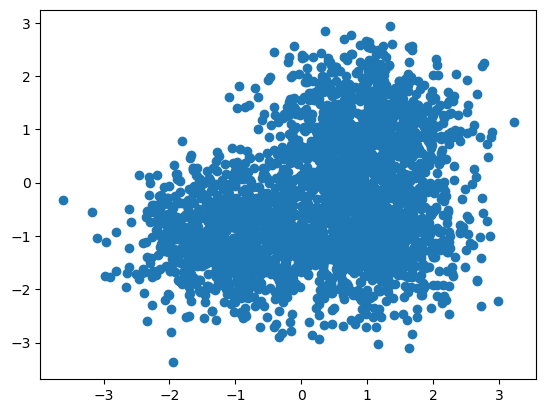

In [27]:
print(X.shape)
plt.scatter(X[:,0], X[:,1])

## Cluster the data using [K-means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans )

In [29]:
k_means = KMeans(init='k-means++', n_clusters=3, n_init=10)
t0 = time.time()
k_means.fit(X)
t_batch = time.time() - t0
print(t_batch)

0.11584019660949707


## Clustering the data using [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html#sklearn.cluster.MiniBatchKMeans )

In [30]:
mbk = MiniBatchKMeans(init='k-means++', n_clusters=3, batch_size=batch_size,
                      n_init=10, max_no_improvement=10, verbose=0)
t0 = time.time()
mbk.fit(X)
t_mini_batch = time.time() - t0
print(t_mini_batch)

C:\Users\wesle\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1043: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1024 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


1.956526756286621


## Plot the results

In [31]:
### helper functions
def clust_plot(points, center):
    ax.plot(X[points, 0], X[points, 1], 'o', markerfacecolor=col, marker='o',          markersize=4)
    ax.plot(   center[0],    center[1], '+', markerfacecolor=col, markeredgecolor='k', markersize=16)

def set_fig(title, time, inertia):
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())
    plt.text(-3.5, 1.8, 'train time: %.2fs\ninertia: %f' %(time, inertia))
    


Plot K-means and mini batch K-means and the differences between them in three subplots.


KMeans Centers: [[ 1.07705469 -1.06730994]
 [-1.07094261 -1.00512907]
 [ 0.96835544  1.01900336]]
MiniBatch KMeans Centers: [[ 1.10581636 -1.09707502]
 [-1.02823747 -0.96749068]
 [ 0.96229998  1.00705313]]
(3,)
Re-ordered MBKmeans Centers: [[ 1.10581636 -1.09707502]
 [-1.02823747 -0.96749068]
 [ 0.96229998  1.00705313]]


C:\Users\wesle\AppData\Local\Temp\ipykernel_16284\1375951831.py:3: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(X[points, 0], X[points, 1], 'o', markerfacecolor=col, marker='o',          markersize=4)


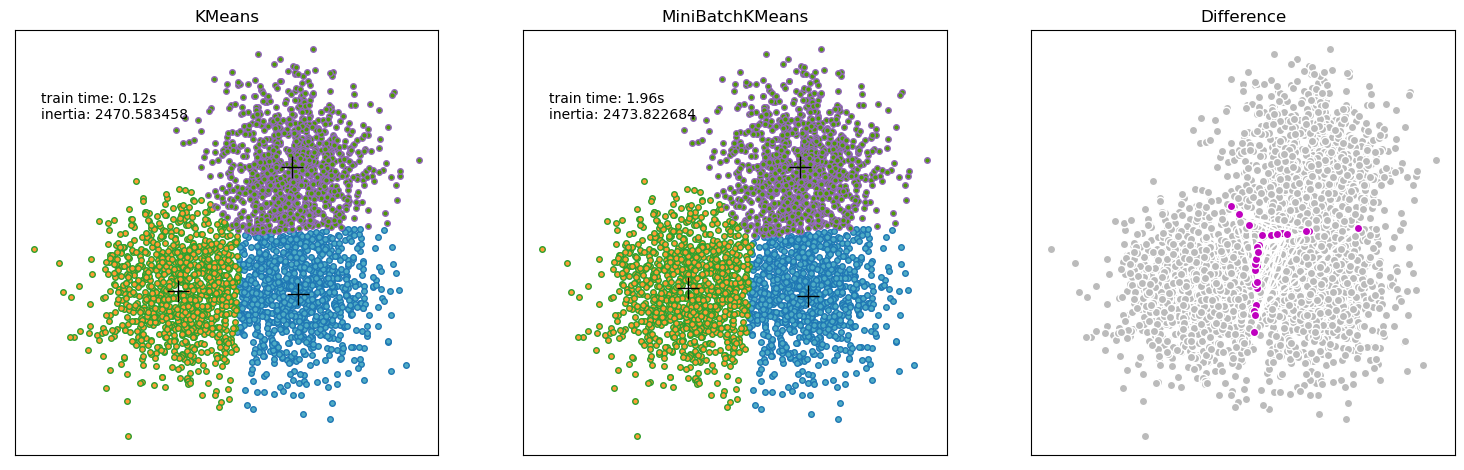

In [47]:
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ['#4EACC5', '#FF9C34', '#4E9A06']
# We want to have the same colours for the same cluster from the MiniBatchKMeans and the KMeans 
# algorithm. Let's pair the cluster centers per closest one.

k_centers = k_means.cluster_centers_
order = pairwise_distances_argmin(k_means.cluster_centers_, mbk.cluster_centers_)
print (f'KMeans Centers: {k_means.cluster_centers_}')
print (f'MiniBatch KMeans Centers: {mbk.cluster_centers_}')
print (np.flip(order).shape)
mbk_centers = mbk.cluster_centers_[order]
print(f'Re-ordered MBKmeans Centers: {mbk.cluster_centers_}')

k_labels   = pairwise_distances_argmin(X, k_centers)
mbk_labels = pairwise_distances_argmin(X, mbk_centers)

    
# KMeans-------------------------------------------------------------------------------------------------------
ax = fig.add_subplot(1, 3, 1)
for k, col in zip(range(n_clusters), colors):
    clust_points = k_labels == k
    clust_center = k_centers[k]
    clust_plot(clust_points, clust_center)

set_fig('KMeans', t_batch, k_means.inertia_)  #inertia or within-clusters sum-of-squares criterion

# MiniBatchKMeans-----------------------------------------------------------------------------------------------
ax = fig.add_subplot(1, 3, 2)
for k, col in zip(range(n_clusters), colors):
    clust_points = mbk_labels == k
    clust_center = mbk_centers[k]
    clust_plot(clust_points, clust_center)

set_fig('MiniBatchKMeans', t_mini_batch, mbk.inertia_)
    
# Initialise the different array to all False-------------------------------------------------------------------
different = (mbk_labels == 4)
ax = fig.add_subplot(1, 3, 3)

for k in range(n_clusters):
    different += ((k_labels == k) != (mbk_labels == k))

identic = np.logical_not(different)
ax.plot(X[identic,   0], X[identic,   1], 'w', markerfacecolor='#bbbbbb', marker='.',markersize=12)
ax.plot(X[different, 0], X[different, 1], 'w', markerfacecolor='m',       marker='.', markersize=12)
ax.set_title('Difference')
ax.set_xticks(())
ax.set_yticks(())

plt.show()
